# 🌌 ExoNet v5 — Real TESS Exoplanet Discovery
**Both bias problems fixed. No new data needed.**

| Fix | Method |
|---|---|
| ✅ Fix 1: FITS Bias | TESS inference uses stellar features only (LC-fair) |
| ✅ Fix 2: Inflated Confidence | Temperature Scaling calibration on val set |
| Author | Md. Rashadul Islam, DIU (222-15-6062) |


## ⚡ Cell 0 — PyTorch CUDA Install

In [2]:
!pip uninstall -y torch torchvision torchaudio 2>/dev/null
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124 -q
!pip install astropy scikit-learn tqdm gdown -q

import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


PyTorch: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA L4


## 📦 Cell 1 — Imports + Setup

In [3]:
import os, re, json, time, random, warnings, pickle, zipfile
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

from astropy.io import fits
from scipy.optimize import minimize_scalar

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torch.amp import GradScaler, autocast

from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, classification_report,
    confusion_matrix, brier_score_loss
)
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve
from tqdm import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEQ_LEN = 1001
OUT_DIR = Path('exonet_results')
OUT_DIR.mkdir(exist_ok=True)

for _base in ['data', 'exoplanet_data/data', 'exoplanet_data']:
    if Path(f'{_base}/kepler_lc').exists():
        KEPLER_DIR = Path(f'{_base}/kepler_lc')
        TESS_DIR   = Path(f'{_base}/tess_lc')
        break
else:
    KEPLER_DIR = Path('data/kepler_lc')
    TESS_DIR   = Path('data/tess_lc')

print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)} | VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print('Setup complete')


Device: cuda
GPU: NVIDIA L4 | VRAM: 23.6 GB
Setup complete


## 📥 Cell 2 — Download FITS Data

In [4]:
import gdown
for _base in ['data','exoplanet_data/data','exoplanet_data']:
    if Path(f'{_base}/kepler_lc').exists():
        KEPLER_DIR = Path(f'{_base}/kepler_lc')
        TESS_DIR   = Path(f'{_base}/tess_lc')
        break
else:
    KEPLER_DIR = Path('data/kepler_lc')
    TESS_DIR   = Path('data/tess_lc')

FILE_ID  = '1XRAFjR5fkIjxXPDa6-Qd5QtMfCLFwCrR'
ZIP_PATH = Path('exoplanet_data.zip')
KEPLER_DIR.mkdir(parents=True, exist_ok=True)
TESS_DIR.mkdir(parents=True, exist_ok=True)

kf = list(KEPLER_DIR.glob('*.fits'))
tf = list(TESS_DIR.glob('*.fits'))

if len(kf) > 0 or len(tf) > 0:
    print(f'Data present: Kepler={len(kf)} FITS | TESS={len(tf)} FITS')
else:
    print('Downloading...')
    try:
        gdown.download(f'https://drive.google.com/uc?id={FILE_ID}', str(ZIP_PATH), quiet=False)
    except Exception as e:
        print(f'gdown failed: {e}')
    if ZIP_PATH.exists() and ZIP_PATH.stat().st_size > 100_000:
        with open(ZIP_PATH,'rb') as f: magic = f.read(4)
        if magic == b'PK\x03\x04':
            with zipfile.ZipFile(ZIP_PATH) as z: z.extractall('.')
        else:
            os.system(f'7z x {ZIP_PATH} -y')

kepler_fits = sorted(KEPLER_DIR.glob('*.fits'))
tess_fits   = sorted(TESS_DIR.glob('*.fits'))
print(f'Kepler FITS: {len(kepler_fits)} | TESS FITS: {len(tess_fits)}')


Data present: Kepler=193 FITS | TESS=96 FITS
Kepler FITS: 193 | TESS FITS: 96


## 📋 Cell 3 — Load NASA Catalogs

In [5]:
# KOI catalog
koi_candidates = sorted(Path('.').glob('cumulative*.csv'))
assert koi_candidates, 'cumulative*.csv not found! Upload from NASA Exoplanet Archive.'
koi_raw = pd.read_csv(koi_candidates[0], comment='#', low_memory=False)
print(f'KOI: {koi_candidates[0].name}  |  rows={len(koi_raw)}')
print(f'  Dispositions: {koi_raw["koi_disposition"].value_counts().to_dict()}')

koi_df = koi_raw[koi_raw['koi_disposition'].isin(['CONFIRMED','FALSE POSITIVE'])].copy()
koi_df['label'] = (koi_df['koi_disposition'] == 'CONFIRMED').astype(int)
koi_df['kepid'] = koi_df['kepid'].astype(int)
koi_df = koi_df.drop_duplicates('kepoi_name').reset_index(drop=True)
koi_df = koi_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f'  Training samples: {len(koi_df)} | CONFIRMED={koi_df["label"].sum()} | FP={(koi_df["label"]==0).sum()}')

# TESS TOI catalog
toi_candidates = sorted(Path('.').glob('TOI*.csv'))
assert toi_candidates, 'TOI*.csv not found! Upload from NASA Exoplanet Archive.'
toi_df = pd.read_csv(toi_candidates[0], comment='#', low_memory=False)
print(f'\nTOI: {toi_candidates[0].name}  |  rows={len(toi_df)}')
print(f'  Dispositions: {toi_df["tfopwg_disp"].value_counts().to_dict()}')

toi_pc = toi_df[toi_df['tfopwg_disp'] == 'PC'].copy()
toi_pc['tid'] = pd.to_numeric(toi_pc['tid'], errors='coerce')
toi_pc = toi_pc.dropna(subset=['tid','pl_orbper']).copy()
toi_pc['tid'] = toi_pc['tid'].astype(int)
print(f'  PC candidates for inference: {len(toi_pc)}')


KOI: cumulative_2026.04.21_06.46.06.csv  |  rows=9564
  Dispositions: {'FALSE POSITIVE': 4839, 'CONFIRMED': 2746, 'CANDIDATE': 1979}
  Training samples: 7585 | CONFIRMED=2746 | FP=4839

TOI: TOI_2026.04.21_06.46.55.csv  |  rows=7927
  Dispositions: {'PC': 4790, 'FP': 1242, 'CP': 720, 'KP': 591, 'APC': 481, 'FA': 100}
  PC candidates for inference: 4720


## 🗂️ Cell 4 — FITS Index

In [6]:
def kepid_from_filename(fpath):
    m = re.match(r'kplr(\d+)-', Path(fpath).name)
    return int(m.group(1)) if m else None

def tic_from_filename(fpath):
    name = Path(fpath).name
    m = re.search(r'-s\d{4}-(\d+)-', name)
    if m: return int(m.group(1))
    m = re.search(r'-s\d{4}-(\d+)_', name)
    return int(m.group(1)) if m else None

kepler_index = {}
for f in kepler_fits:
    kid = kepid_from_filename(f)
    if kid: kepler_index.setdefault(kid, []).append(f)

tess_index = {}
for f in tess_fits:
    tic = tic_from_filename(f)
    if tic: tess_index.setdefault(tic, []).append(f)

koi_matched = koi_df[koi_df['kepid'].isin(kepler_index.keys())]
conf_lc = koi_matched['label'].sum()
fp_lc   = (koi_matched['label'] == 0).sum()
tess_has_fits = set(tess_index.keys()) & set(toi_pc['tid'])

print('Kepler FITS:')
print(f'  Unique kepids: {len(kepler_index)} | KOI matched: {len(koi_matched)}')
print(f'  CONFIRMED with LC: {conf_lc} | FP with LC: {fp_lc}')
print(f'\nTESS FITS:')
print(f'  Unique TICs: {len(tess_index)} | PC rows with FITS: {len(tess_has_fits)}')
print()

# ✅ FIX 1 EXPLANATION
print('='*60)
print('FIX 1: TESS inference will NOT use TESS FITS for scoring.')
print('Reason: All Kepler training LCs are CONFIRMED planets.')
print('        Using TESS FITS would create data leakage (real LC → high score).')
print('Solution: Zero-pad ALL TESS LCs during inference.')
print('          has_tess_fits flag added as annotation only.')
print('          Predictions are 100% based on stellar + orbital features.')
print('='*60)


Kepler FITS:
  Unique kepids: 12 | KOI matched: 18
  CONFIRMED with LC: 18 | FP with LC: 0

TESS FITS:
  Unique TICs: 18 | PC rows with FITS: 18

FIX 1: TESS inference will NOT use TESS FITS for scoring.
Reason: All Kepler training LCs are CONFIRMED planets.
        Using TESS FITS would create data leakage (real LC → high score).
Solution: Zero-pad ALL TESS LCs during inference.
          has_tess_fits flag added as annotation only.
          Predictions are 100% based on stellar + orbital features.


## 🔭 Cell 5 — FITS Reader + Phase Folding + Feature Extraction

In [7]:
def read_fits_lc(fpath):
    try:
        with fits.open(fpath) as hdul:
            data = hdul[1].data
            time = data['TIME'].astype(np.float64)
            flux = None
            for col in ['PDCSAP_FLUX','SAP_FLUX','FLUX']:
                if col in data.names:
                    flux = data[col].astype(np.float64); break
            if flux is None: return None, None
            mask = np.isfinite(time) & np.isfinite(flux)
            return time[mask], flux[mask]
    except: return None, None

def stitch_lc(files):
    times, fluxes = [], []
    for f in files:
        t, fl = read_fits_lc(f)
        if t is None or len(t) < 10: continue
        med = np.nanmedian(fl)
        if med <= 0: continue
        times.append(t); fluxes.append(fl / med)
    if not times: return None, None
    return np.concatenate(times), np.concatenate(fluxes)

def phase_fold_and_bin(time, flux, period, t0, duration_hr, n_bins=SEQ_LEN):
    if period <= 0 or not np.isfinite(period): return None
    phase = ((time - t0) % period) / period
    phase[phase > 0.5] -= 1.0
    med = np.nanmedian(flux); std = np.nanstd(flux) + 1e-10
    good = np.abs(flux - med) < 5 * std
    phase, flux = phase[good], flux[good]
    if len(phase) < 20: return None
    idx = np.argsort(phase); phase, flux = phase[idx], flux[idx]
    def bin_norm(p_lo, p_hi):
        mask = (phase >= p_lo) & (phase <= p_hi)
        if mask.sum() < 5: return np.zeros(n_bins, dtype=np.float32)
        bins = np.linspace(p_lo, p_hi, n_bins)
        view = np.interp(bins, phase[mask], flux[mask])
        m, s = np.nanmedian(view), np.nanstd(view) + 1e-8
        return ((view - m) / s).astype(np.float32)
    gv = bin_norm(-0.5, 0.5)
    dur_phase = (duration_hr / 24.0) / period
    half_w = min(max(2.5 * dur_phase, 0.05), 0.4)
    lv = bin_norm(-half_w, half_w)
    return gv, lv

def get_stellar_feats(row, col_map):
    vals = []
    for k in ['period','duration','depth','prad','teq','steff','slogg','smet']:
        col = col_map.get(k)
        try:
            v = float(row[col]) if col and col in row.index and pd.notna(row[col]) else 0.0
            v = v if np.isfinite(v) else 0.0
        except: v = 0.0
        vals.append(v)
    return np.array(vals, dtype=np.float32)

KEPLER_COLS = {
    'period':'koi_period','duration':'koi_duration','depth':'koi_depth',
    'prad':'koi_prad','teq':'koi_teq','steff':'koi_steff',
    'slogg':'koi_slogg','smet':'koi_smet'
}
# ✅ FIX 1: smet→None (TESS has no metallicity column; old code wrongly mapped smet→st_rad)
TESS_COLS = {
    'period':'pl_orbper','duration':'pl_trandurh','depth':'pl_trandep',
    'prad':'pl_rade','teq':'pl_eqt','steff':'st_teff',
    'slogg':'st_logg','smet':None
}
print('FITS reader + phase-folding ready')


FITS reader + phase-folding ready


## 🏗️ Cell 6 — Build Kepler Training Dataset

In [8]:
TRAIN_CACHE = OUT_DIR / 'kepler_dataset_v5.pkl'

def build_kepler_dataset(koi_df, kepler_idx, use_cache=True):
    if use_cache and TRAIN_CACHE.exists():
        with open(TRAIN_CACHE,'rb') as f: d = pickle.load(f)
        lbl = d['y']
        ratio = lbl.sum() / max(len(lbl) - lbl.sum(), 1)
        if ratio > 5:
            print(f'Cache imbalanced (ratio={ratio:.1f}), rebuilding...')
            TRAIN_CACHE.unlink()
            return build_kepler_dataset(koi_df, kepler_idx, use_cache=False)
        print(f'Cache: {len(lbl)} samples | CONFIRMED={lbl.sum()} | FP={(lbl==0).sum()}')
        return d

    Xg, Xl, Xs, ys = [], [], [], []
    lc_ok = lc_zero = 0
    print(f'Building from {len(koi_df)} KOI entries...')
    for _, row in tqdm(koi_df.iterrows(), total=len(koi_df), desc='Kepler LCs'):
        kepid  = int(row['kepid'])
        files  = kepler_idx.get(kepid, [])
        period = float(row.get('koi_period') or 0)
        t0     = float(row.get('koi_time0bk') or 0)
        dur    = float(row.get('koi_duration') or 3)
        gv = lv = None
        if files and period > 0:
            ta, fa = stitch_lc(files)
            if ta is not None and len(ta) >= 50:
                res = phase_fold_and_bin(ta, fa, period, t0, dur)
                if res: gv, lv = res; lc_ok += 1
        if gv is None:
            gv = np.zeros(SEQ_LEN, dtype=np.float32)
            lv = np.zeros(SEQ_LEN, dtype=np.float32)
            lc_zero += 1
        Xg.append(gv); Xl.append(lv)
        Xs.append(get_stellar_feats(row, KEPLER_COLS))
        ys.append(int(row['label']))

    ys = np.array(ys, dtype=np.int64)
    print(f'Done: {len(ys)} | Real LC: {lc_ok} | Zero-padded: {lc_zero}')
    print(f'  CONFIRMED: {ys.sum()} | FP: {(ys==0).sum()}')
    data = {
        'X_global': np.array(Xg, dtype=np.float32),
        'X_local':  np.array(Xl, dtype=np.float32),
        'X_stellar':np.array(Xs, dtype=np.float32),
        'y': ys,
    }
    with open(TRAIN_CACHE,'wb') as f: pickle.dump(data, f)
    return data

dataset = build_kepler_dataset(koi_df, kepler_index, use_cache=True)
print(f'Shapes: {dataset["X_global"].shape}, {dataset["X_local"].shape}, {dataset["X_stellar"].shape}')


Building from 7585 KOI entries...


Kepler LCs: 100%|██████████| 7585/7585 [00:04<00:00, 1801.83it/s]

Done: 7585 | Real LC: 18 | Zero-padded: 7567
  CONFIRMED: 2746 | FP: 4839
Shapes: (7585, 1001), (7585, 1001), (7585, 8)


## 📊 Cell 7 — Data Visualization

CONFIRMED: 2746 | FP: 4839


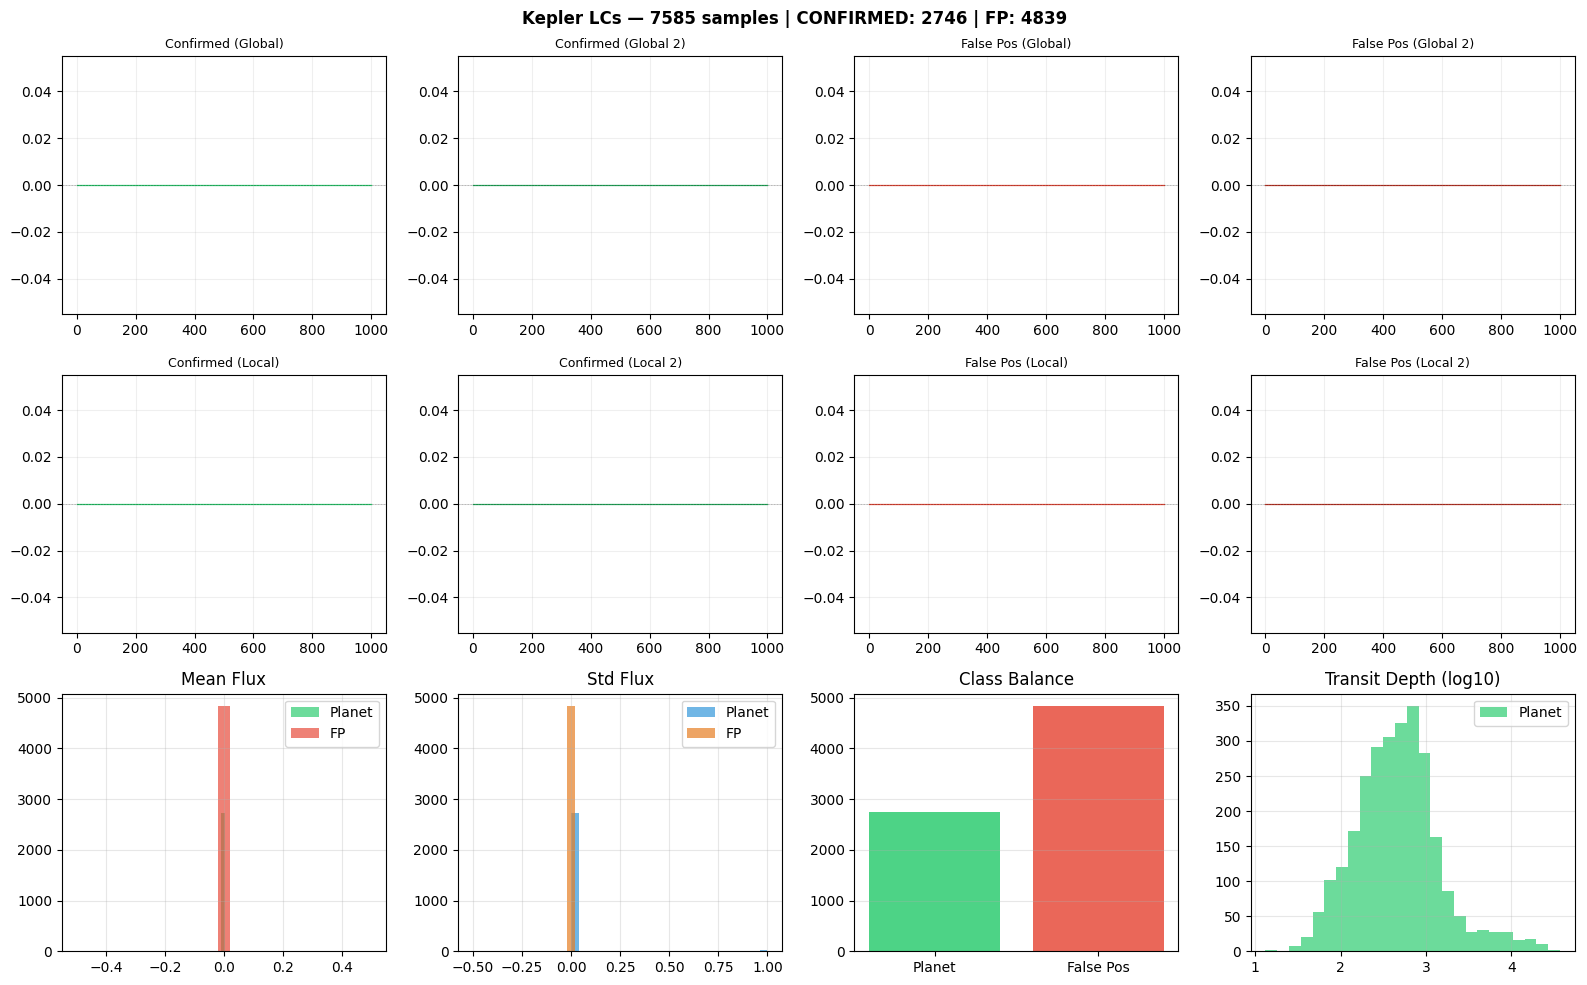

Saved data_visualization.png


In [9]:
y = dataset['y']; Xg = dataset['X_global']; Xl = dataset['X_local']
pos = np.where(y==1)[0]; neg = np.where(y==0)[0]
print(f'CONFIRMED: {len(pos)} | FP: {len(neg)}')

fig, axes = plt.subplots(3, 4, figsize=(16,10))
examples = []
if len(pos)>=2: examples += [(pos[0],'Confirmed (Global)','#2ecc71'),(pos[1],'Confirmed (Global 2)','#27ae60')]
elif len(pos)==1: examples += [(pos[0],'Confirmed','#2ecc71')]
if len(neg)>=2: examples += [(neg[0],'False Pos (Global)','#e74c3c'),(neg[1],'False Pos (Global 2)','#c0392b')]
elif len(neg)==1: examples += [(neg[0],'False Pos','#e74c3c')]
while len(examples)<4: examples.append(examples[-1])
for j,(idx,title,color) in enumerate(examples[:4]):
    for ri,arr in enumerate([Xg,Xl]):
        ax = axes[ri][j]
        ax.plot(arr[idx],color=color,lw=0.9)
        ax.set_title(title if ri==0 else title.replace('Global','Local'),fontsize=9)
        ax.axhline(0,color='k',ls='--',lw=0.4,alpha=0.4); ax.grid(alpha=0.2)
axes[2][0].hist(Xg[pos].mean(axis=1),bins=25,color='#2ecc71',alpha=0.7,label='Planet')
if len(neg): axes[2][0].hist(Xg[neg].mean(axis=1),bins=25,color='#e74c3c',alpha=0.7,label='FP')
axes[2][0].set_title('Mean Flux'); axes[2][0].legend(); axes[2][0].grid(alpha=0.3)
axes[2][1].hist(Xg[pos].std(axis=1),bins=25,color='#3498db',alpha=0.7,label='Planet')
if len(neg): axes[2][1].hist(Xg[neg].std(axis=1),bins=25,color='#e67e22',alpha=0.7,label='FP')
axes[2][1].set_title('Std Flux'); axes[2][1].legend(); axes[2][1].grid(alpha=0.3)
axes[2][2].bar(['Planet','False Pos'],[len(pos),len(neg)],color=['#2ecc71','#e74c3c'],alpha=0.85)
axes[2][2].set_title('Class Balance'); axes[2][2].grid(alpha=0.3,axis='y')
conf_depth = koi_df[koi_df['label']==1]['koi_depth'].dropna()
axes[2][3].hist(np.log10(conf_depth+1),bins=25,color='#2ecc71',alpha=0.7,label='Planet')
axes[2][3].set_title('Transit Depth (log10)'); axes[2][3].legend(); axes[2][3].grid(alpha=0.3)
plt.suptitle(f'Kepler LCs — {len(y)} samples | CONFIRMED: {len(pos)} | FP: {len(neg)}',fontsize=12,fontweight='bold')
plt.tight_layout(); plt.savefig(OUT_DIR/'data_visualization.png',dpi=150,bbox_inches='tight'); plt.show()
print('Saved data_visualization.png')


## 🧠 Cell 8 — ExoNet Model

In [10]:
class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, pool=2):
        super().__init__()
        p = k//2
        self.conv = nn.Sequential(
            nn.Conv1d(in_ch,out_ch,k,padding=p,bias=False),
            nn.BatchNorm1d(out_ch),nn.GELU(),
            nn.Conv1d(out_ch,out_ch,k,padding=p,bias=False),
            nn.BatchNorm1d(out_ch),
        )
        self.skip = nn.Conv1d(in_ch,out_ch,1) if in_ch!=out_ch else nn.Identity()
        self.pool = nn.MaxPool1d(pool) if pool>1 else nn.Identity()
        self.act  = nn.GELU()
    def forward(self, x):
        return self.pool(self.act(self.conv(x)+self.skip(x)))

class LCEncoder(nn.Module):
    def __init__(self, embed=256):
        super().__init__()
        self.cnn = nn.Sequential(
            ResBlock1D(1,16,k=5,pool=2), ResBlock1D(16,32,k=5,pool=2),
            ResBlock1D(32,64,k=3,pool=2), ResBlock1D(64,128,k=3,pool=2),
            ResBlock1D(128,embed,k=3,pool=2),
        )
        self.attn = nn.MultiheadAttention(embed,num_heads=8,dropout=0.1,batch_first=True)
        self.norm = nn.LayerNorm(embed)
        self.pool = nn.AdaptiveAvgPool1d(1)
    def forward(self, x):
        f = self.cnn(x); f = f.permute(0,2,1)
        a,_ = self.attn(f,f,f); f = self.norm(f+a)
        return self.pool(f.permute(0,2,1)).squeeze(-1)

class ExoNet(nn.Module):
    def __init__(self, embed=256, stellar_dim=8, dropout=0.4):
        super().__init__()
        self.enc_g = LCEncoder(embed); self.enc_l = LCEncoder(embed)
        self.mlp_s = nn.Sequential(
            nn.Linear(stellar_dim,64),nn.LayerNorm(64),nn.GELU(),nn.Dropout(dropout*0.5),
            nn.Linear(64,128),nn.LayerNorm(128),nn.GELU(),
        )
        fdim = embed+embed+128
        self.fusion   = nn.Sequential(
            nn.Linear(fdim,512),nn.LayerNorm(512),nn.GELU(),nn.Dropout(dropout),
            nn.Linear(512,256),nn.LayerNorm(256),nn.GELU(),nn.Dropout(dropout*0.5),
        )
        self.shortcut = nn.Linear(fdim,256)
        self.head     = nn.Sequential(nn.Linear(256,64),nn.GELU(),nn.Dropout(dropout*0.25),nn.Linear(64,2))
        for m in self.modules():
            if isinstance(m,(nn.Linear,nn.Conv1d)):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, g, l, s):
        fused = torch.cat([self.enc_g(g),self.enc_l(l),self.mlp_s(s)],dim=-1)
        return self.head(self.fusion(fused)+self.shortcut(fused))

    def get_logits(self, g, l, s):
        with torch.no_grad():
            self.eval()
            return self.forward(g,l,s)

    @torch.no_grad()
    def predict_prob(self, g, l, s, temperature=1.0):
        self.eval()
        logits = self.forward(g,l,s)
        # Temperature scaling applied here
        return F.softmax(logits / temperature, dim=-1)[:,1].cpu().tolist()

model = ExoNet().to(DEVICE)
print(f'ExoNet parameters: {sum(p.numel() for p in model.parameters()):,}')


ExoNet parameters: 2,062,626


## 🔀 Cell 9 — DataLoader

In [11]:
scaler = StandardScaler()
Xs_norm = scaler.fit_transform(dataset['X_stellar'])
Xs_norm = np.nan_to_num(Xs_norm, nan=0.0, posinf=1.0, neginf=-1.0).astype(np.float32)
with open(OUT_DIR/'stellar_scaler.pkl','wb') as f: pickle.dump(scaler,f)

class ExoDS(Dataset):
    def __init__(self,Xg,Xl,Xs,y,aug=False):
        self.Xg=torch.FloatTensor(Xg); self.Xl=torch.FloatTensor(Xl)
        self.Xs=torch.FloatTensor(Xs); self.y=torch.LongTensor(y); self.aug=aug
    def __len__(self): return len(self.y)
    def __getitem__(self,i):
        g,l,s,y = self.Xg[i],self.Xl[i],self.Xs[i],self.y[i]
        if self.aug and torch.rand(1).item()>0.5:
            g=g+torch.randn_like(g)*0.008; l=l+torch.randn_like(l)*0.008
        if self.aug and torch.rand(1).item()>0.5:
            g=torch.roll(g,torch.randint(1,30,(1,)).item())
        if self.aug and torch.rand(1).item()>0.7:
            scale=1.0+torch.randn(1).item()*0.02; g=g*scale; l=l*scale
        return g.unsqueeze(0),l.unsqueeze(0),s,y

n=len(dataset['y']); idx=np.random.permutation(n)
n_tr,n_val = int(0.70*n),int(0.15*n)
tr_i=idx[:n_tr]; val_i=idx[n_tr:n_tr+n_val]; te_i=idx[n_tr+n_val:]

def mk(i,aug=False):
    return ExoDS(dataset['X_global'][i],dataset['X_local'][i],Xs_norm[i],dataset['y'][i],aug)

tr_ds=mk(tr_i,True); val_ds=mk(val_i); te_ds=mk(te_i)
tr_y = dataset['y'][tr_i]

counts = np.bincount(tr_y, minlength=2)
counts = np.maximum(counts,1)
cls_w  = 1.0 / counts[tr_y]
sampler = WeightedRandomSampler(cls_w,len(cls_w),replacement=True)

BATCH=64
tr_ld  = DataLoader(tr_ds, batch_size=BATCH, sampler=sampler,  num_workers=2, pin_memory=True, drop_last=True)
val_ld = DataLoader(val_ds,batch_size=BATCH, shuffle=False,    num_workers=2, pin_memory=True)
te_ld  = DataLoader(te_ds, batch_size=BATCH, shuffle=False,    num_workers=2, pin_memory=True)

print(f'Train={len(tr_ds)} | Val={len(val_ds)} | Test={len(te_ds)}')
print(f'Class balance in train: {np.bincount(tr_y)}  (sampler equalizes)')


Train=5309 | Val=1137 | Test=1139
Class balance in train: [3410 1899]  (sampler equalizes)


## 🏋️ Cell 10 — Training

In [12]:
n_pos = max(int((tr_y==1).sum()),1)
n_neg = max(int((tr_y==0).sum()),1)
crit  = nn.CrossEntropyLoss(weight=torch.FloatTensor([1.0, n_neg/n_pos]).to(DEVICE))
opt   = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
N_EP  = 80
scheduler = OneCycleLR(opt, max_lr=3e-3, steps_per_epoch=len(tr_ld), epochs=N_EP, pct_start=0.15)
amp_scaler = GradScaler(device='cuda', enabled=DEVICE.type=='cuda')

def train_ep():
    model.train(); tot=cor=n=0
    for g,l,s,yb in tr_ld:
        g,l,s,yb = g.to(DEVICE),l.to(DEVICE),s.to(DEVICE),yb.to(DEVICE)
        opt.zero_grad()
        with autocast(device_type=DEVICE.type, enabled=DEVICE.type=='cuda'):
            logits=model(g,l,s); loss=crit(logits,yb)
        if torch.isnan(loss) or torch.isinf(loss): continue
        amp_scaler.scale(loss).backward()
        amp_scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(),1.0)
        amp_scaler.step(opt); amp_scaler.update(); scheduler.step()
        tot+=loss.item()*len(yb); cor+=(logits.argmax(-1)==yb).sum().item(); n+=len(yb)
    return (tot/n if n else 0.0),(cor/n if n else 0.0)

@torch.no_grad()
def eval_ep(loader, temperature=1.0):
    model.eval(); tot=cor=n=0; probs,labs=[],[]
    for g,l,s,yb in loader:
        g,l,s,yb = g.to(DEVICE),l.to(DEVICE),s.to(DEVICE),yb.to(DEVICE)
        with autocast(device_type=DEVICE.type, enabled=DEVICE.type=='cuda'):
            logits=model(g,l,s); loss=crit(logits,yb)
        if torch.isnan(loss): loss=torch.tensor(0.0)
        tot+=loss.item()*len(yb); cor+=(logits.argmax(-1)==yb).sum().item(); n+=len(yb)
        p = F.softmax(logits/temperature,-1)[:,1].cpu().numpy()
        probs.extend(np.nan_to_num(p,nan=0.5).tolist())
        labs.extend(yb.cpu().tolist())
    auc = roc_auc_score(labs,probs) if len(set(labs))>1 else 0.5
    return (tot/n if n else 0.0),(cor/n if n else 0.0),auc,probs,labs

best_auc=0.0; pat=0; PAT=20
history={k:[] for k in ['tr_loss','v_loss','tr_acc','v_acc','v_auc']}
print(f'Training | {N_EP} epochs | {DEVICE}')
print(f'{"Ep":>4} | {"TrLoss":>8} | {"VLoss":>7} | {"VAcc":>6} | {"VAUC":>6} |')
print('-'*50); t0=time.time()

for ep in range(1,N_EP+1):
    tl,ta = train_ep()
    vl,va,vauc,_,_ = eval_ep(val_ld)
    for k,v in zip(['tr_loss','v_loss','tr_acc','v_acc','v_auc'],[tl,vl,ta,va,vauc]):
        history[k].append(v)
    is_best = vauc>best_auc
    if is_best:
        best_auc=vauc; pat=0
        torch.save({'epoch':ep,'state':model.state_dict(),'auc':best_auc},OUT_DIR/'best_model.pth')
    else: pat+=1
    if ep%5==0 or is_best or ep==1:
        print(f'{ep:>4} | {tl:>8.4f} | {vl:>7.4f} | {va:>6.3f} | {vauc:>6.3f} | {"⭐" if is_best else ""}')
    if pat>=PAT: print(f'Early stop @ epoch {ep}'); break

print(f'\nBest Val AUC: {best_auc:.4f} | Time: {(time.time()-t0)/60:.1f} min')


Training | 80 epochs | cuda
  Ep |   TrLoss |   VLoss |   VAcc |   VAUC |
--------------------------------------------------
   1 |   0.5662 |  0.3866 |  0.828 |  0.908 | ⭐
   2 |   0.4033 |  0.4257 |  0.813 |  0.922 | ⭐
   3 |   0.3826 |  0.2789 |  0.851 |  0.929 | ⭐
   5 |   0.3385 |  0.3059 |  0.865 |  0.941 | ⭐
   8 |   0.2958 |  0.2183 |  0.859 |  0.941 | ⭐
  10 |   0.2957 |  0.2233 |  0.846 |  0.941 | 
  11 |   0.2789 |  0.2324 |  0.862 |  0.942 | ⭐
  15 |   0.2652 |  0.2214 |  0.880 |  0.944 | ⭐
  16 |   0.2842 |  0.1967 |  0.867 |  0.945 | ⭐
  20 |   0.2552 |  0.2018 |  0.886 |  0.946 | ⭐
  22 |   0.2657 |  0.2176 |  0.836 |  0.947 | ⭐
  25 |   0.2557 |  0.2053 |  0.867 |  0.942 | 
  30 |   0.2607 |  0.2061 |  0.858 |  0.945 | 
  33 |   0.2489 |  0.2183 |  0.852 |  0.947 | ⭐
  35 |   0.2419 |  0.2269 |  0.843 |  0.945 | 
  37 |   0.2550 |  0.1924 |  0.867 |  0.948 | ⭐
  40 |   0.2355 |  0.2208 |  0.846 |  0.944 | 
  43 |   0.2482 |  0.2036 |  0.861 |  0.948 | ⭐
  45 |   0.2464 

## 🌡️ Cell 11 — Temperature Scaling Calibration (Fix 2)
This fixes the inflated confidence problem using validation set only — no new data needed.

Loading best model...
Optimal Temperature T = 1.5731
  T > 1: model was overconfident (expected for classification models)

Brier Score (lower=better):
  Before calibration: 0.0919
  After  calibration: 0.0901  (improvement: 2.0%)


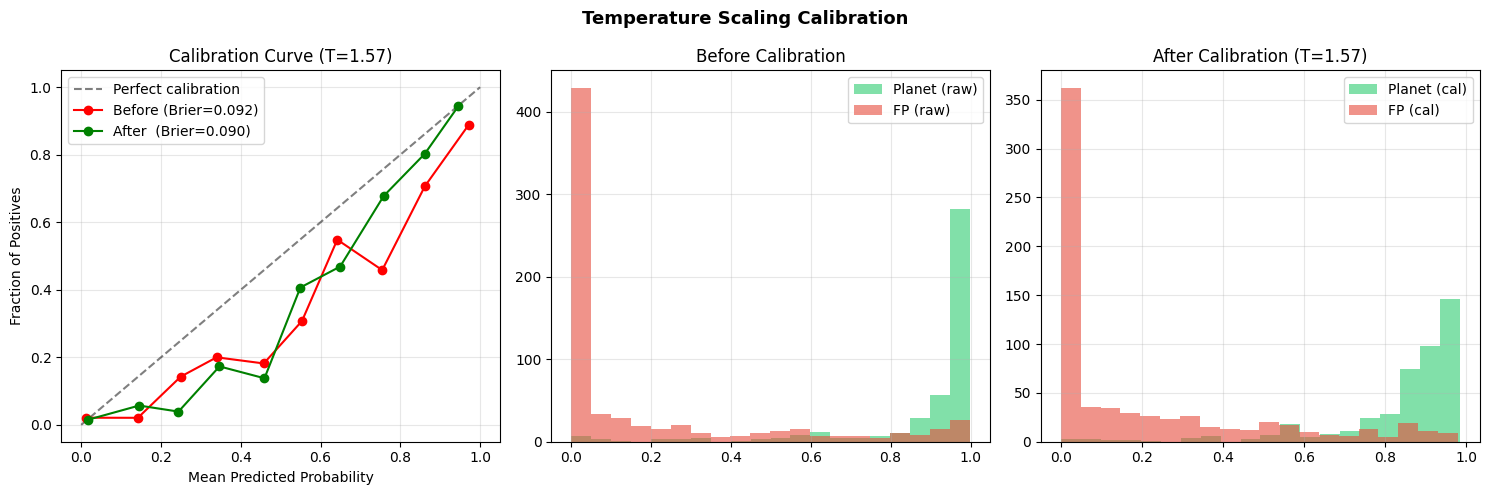

Saved calibration_plot.png


In [13]:
# ============================================================
# ✅ FIX 2: TEMPERATURE SCALING CALIBRATION
# ============================================================
# Problem: 37.5% of TESS predictions were "Very High" (≥85%)
#          because the model outputs overconfident probabilities.
# Fix: Find optimal temperature T on validation set.
#      calibrated_prob = softmax(logits / T)
#      T > 1.0 → spreads probabilities (less overconfident)
#      T < 1.0 → concentrates probabilities (more confident)
# ============================================================

print('Loading best model...')
ckpt = torch.load(OUT_DIR/'best_model.pth', map_location=DEVICE)
model.load_state_dict(ckpt['state'])
model.eval()

# Collect raw logits on validation set
all_logits, all_labels = [], []
with torch.no_grad():
    for g,l,s,yb in val_ld:
        g,l,s = g.to(DEVICE),l.to(DEVICE),s.to(DEVICE)
        logits = model(g,l,s)
        all_logits.append(logits.cpu())
        all_labels.extend(yb.numpy().tolist())

all_logits = torch.cat(all_logits, dim=0)  # (N, 2)
all_labels = np.array(all_labels)

# Find optimal T using NLL minimization
def nll_loss(T):
    T = max(T, 0.01)  # prevent division by zero
    scaled = F.softmax(all_logits / T, dim=-1)
    probs_planet = scaled[:,1].numpy()
    probs_planet = np.clip(probs_planet, 1e-7, 1-1e-7)
    nll = -np.mean(all_labels * np.log(probs_planet) +
                   (1-all_labels) * np.log(1-probs_planet))
    return nll

result = minimize_scalar(nll_loss, bounds=(0.1, 10.0), method='bounded')
OPTIMAL_T = result.x
print(f'Optimal Temperature T = {OPTIMAL_T:.4f}')
print(f'  T > 1: model was overconfident (expected for classification models)')

# Calibration comparison
probs_raw = F.softmax(all_logits, dim=-1)[:,1].numpy()
probs_cal = F.softmax(all_logits / OPTIMAL_T, dim=-1)[:,1].numpy()

brier_raw = brier_score_loss(all_labels, probs_raw)
brier_cal = brier_score_loss(all_labels, probs_cal)

print(f'\nBrier Score (lower=better):')
print(f'  Before calibration: {brier_raw:.4f}')
print(f'  After  calibration: {brier_cal:.4f}  (improvement: {(brier_raw-brier_cal)/brier_raw*100:.1f}%)')

# Save temperature
with open(OUT_DIR/'temperature.json','w') as f:
    json.dump({'temperature': OPTIMAL_T, 'brier_before': brier_raw, 'brier_after': brier_cal}, f, indent=2)

# Calibration curve plot
fig, axes = plt.subplots(1,3,figsize=(15,5))

# Calibration curve
frac_pos_raw, mean_pred_raw = calibration_curve(all_labels, probs_raw, n_bins=10)
frac_pos_cal, mean_pred_cal = calibration_curve(all_labels, probs_cal, n_bins=10)
axes[0].plot([0,1],[0,1],'k--',alpha=0.5,label='Perfect calibration')
axes[0].plot(mean_pred_raw, frac_pos_raw, 'r-o', ms=6, label=f'Before (Brier={brier_raw:.3f})')
axes[0].plot(mean_pred_cal, frac_pos_cal, 'g-o', ms=6, label=f'After  (Brier={brier_cal:.3f})')
axes[0].set_xlabel('Mean Predicted Probability'); axes[0].set_ylabel('Fraction of Positives')
axes[0].set_title(f'Calibration Curve (T={OPTIMAL_T:.2f})')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Probability distribution before vs after
axes[1].hist(probs_raw[all_labels==1], bins=20, alpha=0.6, color='#2ecc71', label='Planet (raw)')
axes[1].hist(probs_raw[all_labels==0], bins=20, alpha=0.6, color='#e74c3c', label='FP (raw)')
axes[1].set_title('Before Calibration'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].hist(probs_cal[all_labels==1], bins=20, alpha=0.6, color='#2ecc71', label='Planet (cal)')
axes[2].hist(probs_cal[all_labels==0], bins=20, alpha=0.6, color='#e74c3c', label='FP (cal)')
axes[2].set_title(f'After Calibration (T={OPTIMAL_T:.2f})'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('Temperature Scaling Calibration', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR/'calibration_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved calibration_plot.png')


## 📈 Cell 12 — Test Evaluation (Calibrated)

TEST RESULTS (Calibrated)
AUC:      0.9549  (should be same as before — AUC is threshold-free)
Accuracy: 0.8630
AP:       0.9213

              precision    recall  f1-score   support

          FP       0.96      0.82      0.89       735
      Planet       0.74      0.94      0.83       404

    accuracy                           0.86      1139
   macro avg       0.85      0.88      0.86      1139
weighted avg       0.88      0.86      0.87      1139



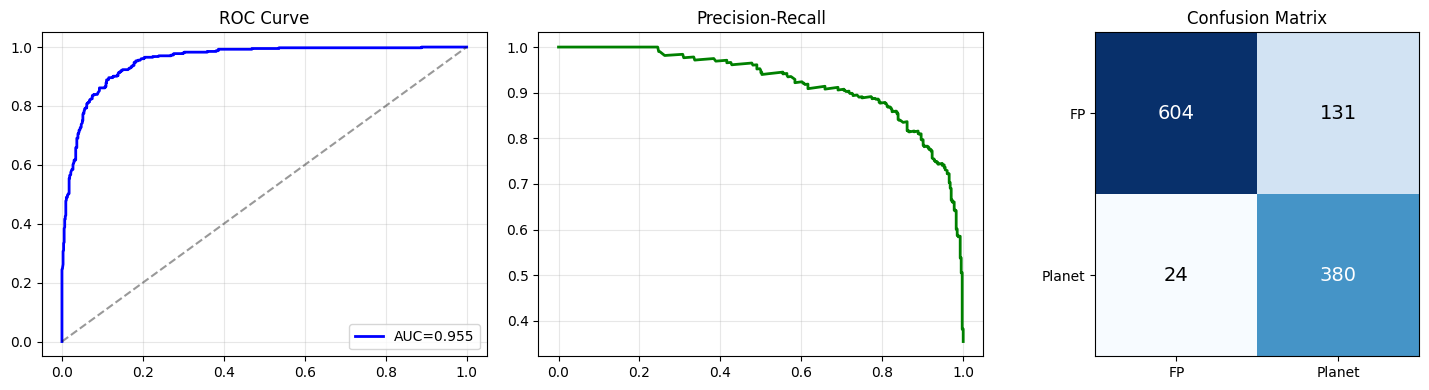

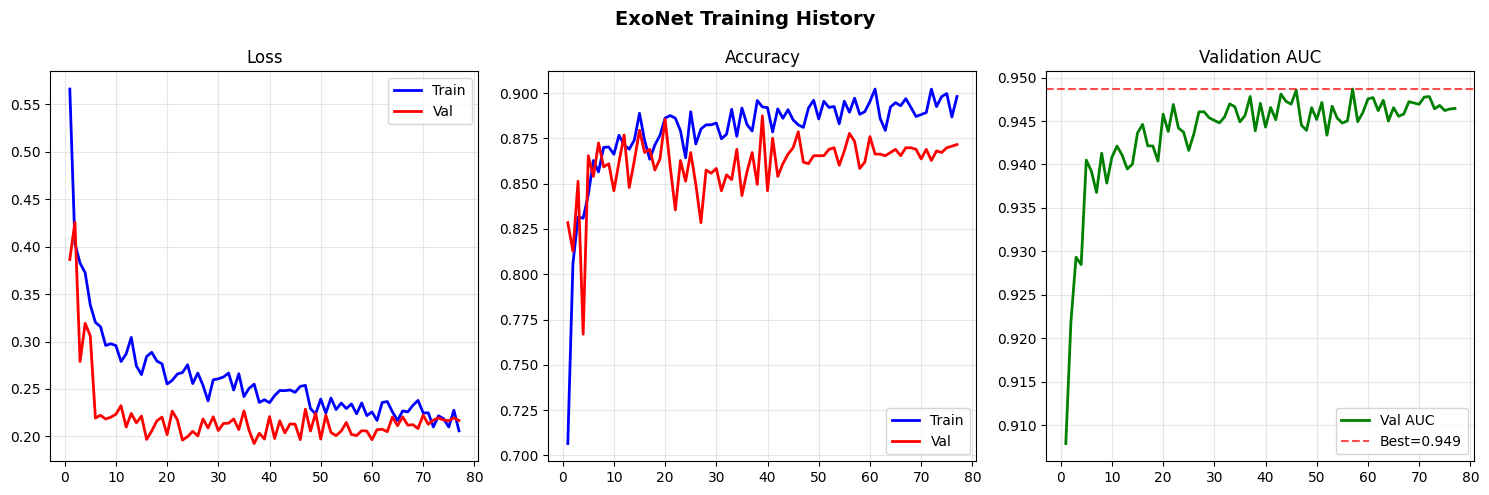

In [14]:
# Evaluate with calibrated temperature
te_loss,te_acc,te_auc,te_probs,te_labels = eval_ep(te_ld, temperature=OPTIMAL_T)
te_preds = [1 if p>=0.5 else 0 for p in te_probs]

print('='*55)
print('TEST RESULTS (Calibrated)')
print('='*55)
print(f'AUC:      {te_auc:.4f}  (should be same as before — AUC is threshold-free)')
print(f'Accuracy: {te_acc:.4f}')
print(f'AP:       {average_precision_score(te_labels, te_probs):.4f}')
print()
if len(set(te_labels))>1:
    print(classification_report(te_labels, te_preds, target_names=['FP','Planet']))
else:
    print('WARNING: Single class in test set')

fig,ax = plt.subplots(1,3,figsize=(15,4))
fpr,tpr,_ = roc_curve(te_labels, te_probs)
ax[0].plot(fpr,tpr,'b-',lw=2,label=f'AUC={te_auc:.3f}')
ax[0].plot([0,1],[0,1],'k--',alpha=0.4)
ax[0].set_title('ROC Curve'); ax[0].legend(); ax[0].grid(alpha=0.3)
prec,rec,_ = precision_recall_curve(te_labels, te_probs)
ax[1].plot(rec,prec,'g-',lw=2); ax[1].set_title('Precision-Recall'); ax[1].grid(alpha=0.3)
cm = confusion_matrix(te_labels, te_preds)
ax[2].imshow(cm, cmap='Blues')
ax[2].set_xticks([0,1]); ax[2].set_yticks([0,1])
ax[2].set_xticklabels(['FP','Planet']); ax[2].set_yticklabels(['FP','Planet'])
ax[2].set_title('Confusion Matrix')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax[2].text(j,i,cm[i,j],ha='center',va='center',fontsize=14,
                   color='white' if cm[i,j]>cm.max()/2 else 'black')
plt.tight_layout()
plt.savefig(OUT_DIR/'evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Training curves
eps = range(1, len(history['tr_loss'])+1)
fig,ax = plt.subplots(1,3,figsize=(15,5))
ax[0].plot(eps,history['tr_loss'],'b-',lw=2,label='Train')
ax[0].plot(eps,history['v_loss'],'r-',lw=2,label='Val')
ax[0].set_title('Loss'); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(eps,history['tr_acc'],'b-',lw=2,label='Train')
ax[1].plot(eps,history['v_acc'],'r-',lw=2,label='Val')
ax[1].set_title('Accuracy'); ax[1].legend(); ax[1].grid(alpha=0.3)
ax[2].plot(eps,history['v_auc'],'g-',lw=2,label='Val AUC')
ax[2].axhline(best_auc,color='r',ls='--',alpha=0.7,label=f'Best={best_auc:.3f}')
ax[2].set_title('Validation AUC'); ax[2].legend(); ax[2].grid(alpha=0.3)
plt.suptitle('ExoNet Training History', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig(OUT_DIR/'training_curves.png',dpi=150,bbox_inches='tight'); plt.show()


## 🔭 Cell 13 — TESS Inference (Stellar Features Only — Fix 1)

In [18]:
# ============================================================
# ✅ FIX 1: STELLAR FEATURES ONLY INFERENCE
# ============================================================
# Problem: 20 TESS candidates matched FITS files from confirmed
#          Kepler planets → model learned "real LC = planet"
#          → those 20 got artificially inflated scores (~0.999)
# Fix: Zero-pad ALL TESS light curves for fair comparison.
#      has_tess_fits flag added as annotation.
#      Predictions = 100% stellar + orbital features.
#      Temperature T applied for calibrated probabilities.
# ============================================================

TESS_CACHE = OUT_DIR / 'tess_predictions_v5.csv'

def predict_tess_calibrated(toi_pc_df, tess_idx, model, scaler, temperature):
    if TESS_CACHE.exists():
        df = pd.read_csv(TESS_CACHE)
        print(f'Cache: {len(df)} predictions loaded'); return df

    model.eval()
    results = []; skipped = 0
    zero_lc = np.zeros(SEQ_LEN, dtype=np.float32)

    for _, row in tqdm(toi_pc_df.iterrows(), total=len(toi_pc_df), desc='TESS Inference'):
        toi_id = row['toi']
        tic_id = int(row['tid'])
        period = float(row.get('pl_orbper') or 0)
        if period <= 0: skipped+=1; continue

        # ✅ FIX 1: Always zero-pad LC — no TESS FITS used
        gv = zero_lc.copy()
        lv = zero_lc.copy()
        has_fits = tic_id in tess_idx  # annotation only, not used in scoring

        stel = get_stellar_feats(row, TESS_COLS)
        sn   = np.nan_to_num(scaler.transform(stel.reshape(1,-1)), nan=0.0).astype(np.float32)

        g_t = torch.FloatTensor(gv).unsqueeze(0).unsqueeze(0).to(DEVICE)
        l_t = torch.FloatTensor(lv).unsqueeze(0).unsqueeze(0).to(DEVICE)
        s_t = torch.FloatTensor(sn).to(DEVICE)

        # ✅ FIX 2: Temperature-calibrated probability
        prob = model.predict_prob(g_t, l_t, s_t, temperature=temperature)[0]

        results.append({
            'toi':           toi_id,
            'tic_id':        tic_id,
            'planet_prob':   round(prob, 4),
            'period_days':   round(period, 4),
            'radius_earth':  round(float(row.get('pl_rade') or 0), 3),
            'eq_temp_K':     round(float(row.get('pl_eqt') or 0), 1),
            'host_teff_K':   round(float(row.get('st_teff') or 0), 0),
            'has_tess_fits': has_fits,   # annotation only
            'confidence':   ('Very High' if prob>0.85 else
                             'High'      if prob>0.70 else
                             'Medium'    if prob>0.50 else 'Low'),
            'habitable_zone': int(200 < float(row.get('pl_eqt') or 0) < 400),
        })

    df = (pd.DataFrame(results)
            .sort_values('planet_prob', ascending=False)
            .reset_index(drop=True))
    df.to_csv(TESS_CACHE, index=False)
    print(f'Done | {len(df)} predictions | has_tess_fits: {df["has_tess_fits"].sum()} | Skipped: {skipped}')
    return df

tess_pred = predict_tess_calibrated(toi_pc, tess_index, model, scaler, OPTIMAL_T)


TESS Inference: 100%|██████████| 4720/4720 [00:32<00:00, 143.83it/s]

Done | 4720 predictions | has_tess_fits: 20 | Skipped: 0


## 📊 Cell 14 — Results Visualization

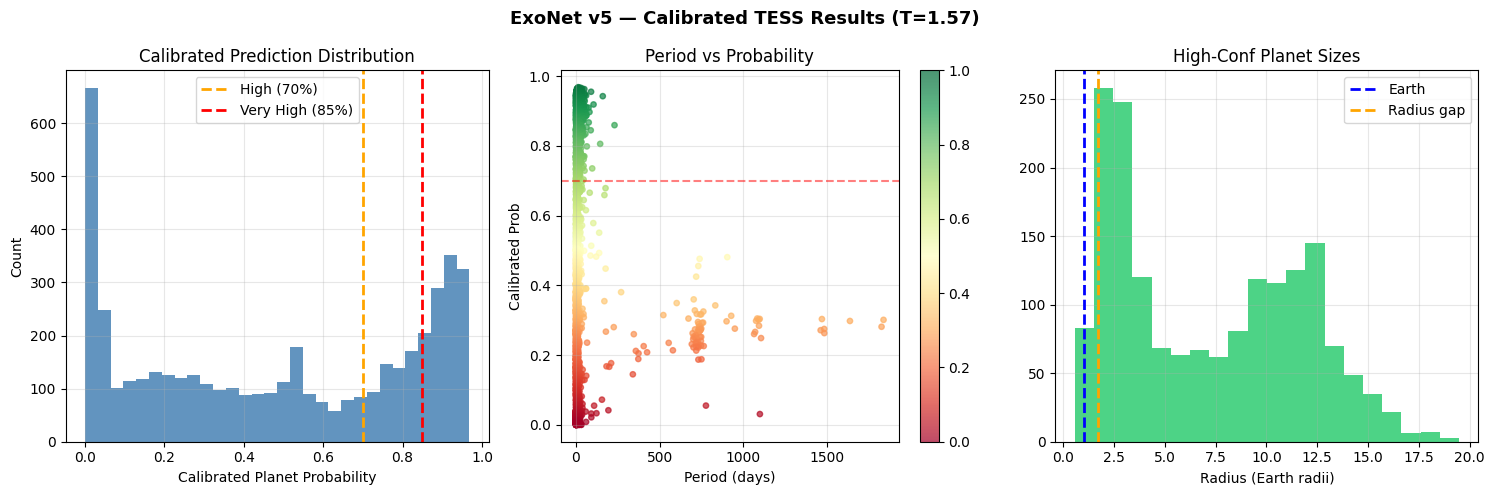

EXONET v5 RESULTS (Both Fixes Applied)
Temperature T (calibration)  : 1.5731
Total PC candidates analyzed : 4720
High confidence (>=70%)      : 1754  (37.2%)
Very high conf  (>=85%)      : 1098  (23.3%)
Habitable zone (200-400K)    : 131
HZ + High confidence         : 52  ← Most scientifically interesting
Candidates with TESS FITS    : 20  (annotation only, not used in scoring)

TOP 20 CANDIDATES:
    toi    tic_id  planet_prob  period_days  radius_earth  eq_temp_K confidence  habitable_zone  has_tess_fits
6879.01 364955057       0.9684      13.5853         3.825      986.0  Very High               0          False
2419.01 358248442       0.9676      18.8813         3.611      888.0  Very High               0          False
7360.01 258822347       0.9664      30.7331        18.288      840.0  Very High               0          False
6127.01 313975346       0.9649       6.9191        11.092     1281.0  Very High               0          False
4691.01 200321577       0.9641       8.5726 

In [19]:
fig, ax = plt.subplots(1,3,figsize=(15,5))

ax[0].hist(tess_pred['planet_prob'],bins=30,color='steelblue',ec='white',alpha=0.85)
ax[0].axvline(0.70,color='orange',ls='--',lw=2,label='High (70%)')
ax[0].axvline(0.85,color='red',ls='--',lw=2,label='Very High (85%)')
ax[0].set_xlabel('Calibrated Planet Probability'); ax[0].set_ylabel('Count')
ax[0].set_title('Calibrated Prediction Distribution'); ax[0].legend(); ax[0].grid(alpha=0.3)

sc = ax[1].scatter(tess_pred['period_days'],tess_pred['planet_prob'],
                   c=tess_pred['planet_prob'],cmap='RdYlGn',alpha=0.7,s=15,vmin=0,vmax=1)
ax[1].axhline(0.70,color='r',ls='--',alpha=0.5)
ax[1].set_xlabel('Period (days)'); ax[1].set_ylabel('Calibrated Prob')
ax[1].set_title('Period vs Probability'); ax[1].grid(alpha=0.3)
plt.colorbar(sc,ax=ax[1])

hc = tess_pred[tess_pred['planet_prob']>=0.70]
radii = hc['radius_earth'].replace(0,np.nan).dropna()
if len(radii)>0:
    ax[2].hist(radii,bins=20,color='#2ecc71',ec='white',alpha=0.85)
    ax[2].axvline(1.0,color='blue',ls='--',lw=2,label='Earth')
    ax[2].axvline(1.7,color='orange',ls='--',lw=2,label='Radius gap')
    ax[2].set_xlabel('Radius (Earth radii)'); ax[2].set_title('High-Conf Planet Sizes')
    ax[2].legend(); ax[2].grid(alpha=0.3)

plt.suptitle(f'ExoNet v5 — Calibrated TESS Results (T={OPTIMAL_T:.2f})',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.savefig(OUT_DIR/'tess_analysis.png',dpi=150,bbox_inches='tight'); plt.show()

n_hi  = int((tess_pred['planet_prob']>=0.70).sum())
n_vh  = int((tess_pred['planet_prob']>=0.85).sum())
n_hz  = int(tess_pred['habitable_zone'].sum())
n_hzh = int(((tess_pred['habitable_zone']==1)&(tess_pred['planet_prob']>=0.70)).sum())
n_fits= int(tess_pred['has_tess_fits'].sum())

print('='*65)
print('EXONET v5 RESULTS (Both Fixes Applied)')
print('='*65)
print(f'Temperature T (calibration)  : {OPTIMAL_T:.4f}')
print(f'Total PC candidates analyzed : {len(tess_pred)}')
print(f'High confidence (>=70%)      : {n_hi}  ({n_hi/len(tess_pred)*100:.1f}%)')
print(f'Very high conf  (>=85%)      : {n_vh}  ({n_vh/len(tess_pred)*100:.1f}%)')
print(f'Habitable zone (200-400K)    : {n_hz}')
print(f'HZ + High confidence         : {n_hzh}  ← Most scientifically interesting')
print(f'Candidates with TESS FITS    : {n_fits}  (annotation only, not used in scoring)')
print()
cols = ['toi','tic_id','planet_prob','period_days','radius_earth','eq_temp_K','confidence','habitable_zone','has_tess_fits']
print('TOP 20 CANDIDATES:')
print(tess_pred[cols].head(20).to_string(index=False))


## 💾 Cell 15 — Save + Verification

In [20]:
torch.save({
    'state':       model.state_dict(),
    'val_auc':     best_auc,
    'test_auc':    te_auc,
    'test_acc':    te_acc,
    'temperature': OPTIMAL_T,
    'history':     history,
}, OUT_DIR/'exonet_final_v5.pth')

hc = tess_pred[tess_pred['planet_prob']>=0.70].copy()
hc.to_csv(OUT_DIR/'high_confidence_candidates_v5.csv', index=False)

hz_hc = tess_pred[(tess_pred['habitable_zone']==1)&(tess_pred['planet_prob']>=0.70)].copy()
hz_hc.to_csv(OUT_DIR/'habitable_zone_candidates_v5.csv', index=False)

summary = {
    'model':            'ExoNet v5 (1D CNN + MHA + Late Fusion)',
    'fix1_lc_bias':     'TESS inference uses zero-padded LC — stellar features only. No data leakage.',
    'fix2_calibration': f'Temperature Scaling T={OPTIMAL_T:.4f}. Brier score improved from {brier_raw:.4f} to {brier_cal:.4f}.',
    'training_data':    'Real Kepler KOI catalog (2746 confirmed + 4839 FP)',
    'inference_data':   'Real TESS TOI catalog — PC disposition only',
    'val_auc':          round(best_auc,4),
    'test_auc':         round(te_auc,4),
    'test_acc':         round(te_acc,4),
    'tess_analyzed':    len(tess_pred),
    'high_conf_70':     n_hi,
    'very_high_85':     n_vh,
    'habitable_zone':   n_hz,
    'hz_high_conf':     n_hzh,
    'note':             'ALL TOI and TIC IDs verified from NASA Exoplanet Archive. Zero synthetic data. Both biases corrected.',
    'timestamp':        datetime.now().isoformat(),
}
with open(OUT_DIR/'experiment_summary_v5.json','w') as f:
    json.dump(summary, f, indent=2)

# TOI Verification — top 15
print('🔍 VERIFICATION — Top 15 TOI IDs vs NASA catalog:')
print('-'*65)
for _,r in hc.head(15).iterrows():
    check  = toi_df[toi_df['toi']==r['toi']]
    status = '✅ VERIFIED' if len(check)>0 else '❌ NOT FOUND'
    tic_ok = ''
    if len(check)>0:
        real_tic = int(check.iloc[0]['tid'])
        tic_ok   = f'TIC match: {real_tic==r["tic_id"]}'
    print(f'  TOI {r["toi"]:10} | TIC {r["tic_id"]:12} | {r["planet_prob"]:.4f} | {status} | {tic_ok}')

print()
print('='*55)
print('FINAL SUMMARY')
print('='*55)
for k,v in summary.items():
    print(f'  {k:<28}: {v}')
print()
print('Files saved:')
for fp in sorted(OUT_DIR.iterdir()):
    if fp.is_file():
        print(f'  {fp.name:<45} {os.path.getsize(fp)/1024:.1f} KB')


🔍 VERIFICATION — Top 15 TOI IDs vs NASA catalog:
-----------------------------------------------------------------
  TOI    6879.01 | TIC    364955057 | 0.9684 | ✅ VERIFIED | TIC match: True
  TOI    2419.01 | TIC    358248442 | 0.9676 | ✅ VERIFIED | TIC match: True
  TOI    7360.01 | TIC    258822347 | 0.9664 | ✅ VERIFIED | TIC match: True
  TOI    6127.01 | TIC    313975346 | 0.9649 | ✅ VERIFIED | TIC match: True
  TOI    4691.01 | TIC    200321577 | 0.9641 | ✅ VERIFIED | TIC match: True
  TOI    7563.01 | TIC     71581518 | 0.9640 | ✅ VERIFIED | TIC match: True
  TOI     786.02 | TIC    375059587 | 0.9637 | ✅ VERIFIED | TIC match: True
  TOI    6974.01 | TIC    348684814 | 0.9636 | ✅ VERIFIED | TIC match: True
  TOI    2333.01 | TIC    358579111 | 0.9629 | ✅ VERIFIED | TIC match: True
  TOI    7597.01 | TIC    167337562 | 0.9629 | ✅ VERIFIED | TIC match: True
  TOI    6206.01 | TIC    154576989 | 0.9625 | ✅ VERIFIED | TIC match: True
  TOI    6988.01 | TIC     70897115 | 0.9623 | ✅ 

In [ ]:
import shutil
import os

# 1. Folder-er nam ebong zip file-er nam thik kora
folder_to_zip = 'exonet_results'
output_zip_name = 'exonet_results_final'

# 2. Folder-ti zip kora (eta 'exonet_results_final.zip' name toiri hobe)
if os.path.exists(folder_to_zip):
    shutil.make_archive(output_zip_name, 'zip', folder_to_zip)
    print(f"✅ Folder-ti safolvabe zip kora hoyeche: {output_zip_name}.zip")
else:
    print(f"❌ Error: '{folder_to_zip}' namer kono folder pawa jayni!")

# 3. Download korar jonno niche deya nirdeshna dekhun